In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [85]:
def potencial_escalar_magnetico(x, z, R, M0):
    """
    Calcula el potencial escalar magnético Phi_M(x, z) de una esfera magnetizada.
    Se utiliza el eje z como el eje de simetría (M_z).
    En coordenadas esféricas: r = sqrt(x^2 + z^2), cos(theta) = z / r.
    """
    r = np.sqrt(x**2 + z**2)
    
    # Manejar el centro (r=0) para evitar división por cero
    # cos_theta = np.where(r != 0, z / r, 1.0)
    cos_theta = z / r # Numpy maneja bien la división por cero en las máscaras.

    # Potencial INTERIOR (r <= R): Phi_M_int = -M0/3 * r * cos(theta)
    Phi_int = -M0 / 3 * r * cos_theta
    
    # Potencial EXTERIOR (r > R): Phi_M_ext = (R^3 * M0) / (3 * r^2) * cos(theta)
    Phi_ext = (R**3 * M0) / (3 * r**2) * cos_theta
    
    # Combinar las dos regiones usando una máscara (np.where)
    Phi_M = np.where(r <= R, Phi_int, Phi_ext)
    
    # Asegurar que el potencial en el origen es 0 (limite)
    Phi_M[r == 0] = 0.0

    return Phi_M

In [86]:
R = 1.0  # Radio de la esfera
M0 = 1.0 # Magnitud de la magnetización (se asume unitaria para la forma)
L = 2.5 # Extensión del área de visualización (-L a L)
puntos = 500 # Número de puntos en cada dimensión

x = np.linspace(-L, L, puntos)
z = np.linspace(-L, L, puntos)
X, Z = np.meshgrid(x, z)

# Calcular el potencial en cada punto de la malla
phi = potencial_escalar_magnetico(X, Z, R, M0)

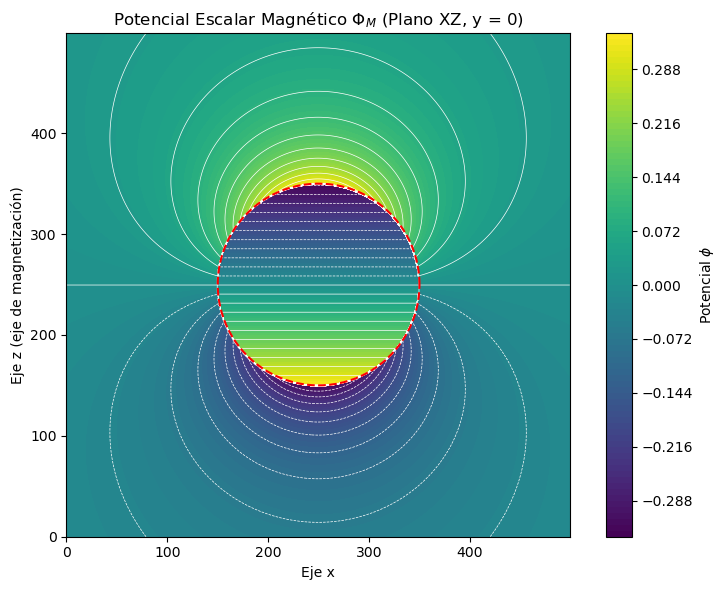

<Figure size 640x480 with 0 Axes>

In [89]:
plt.figure(figsize=(8, 6))

# Mapa de calor
contour = plt.contourf(phi, cmap='viridis', levels=100) 
plt.colorbar(contour, label='Potencial $\phi$')

# Equipotenciales
plt.contour(phi, colors='white', linewidths=0.5, levels=25)

t = np.linspace(0, 2*np.pi,100)
plt.plot(R*puntos*0.5*np.cos(t)/L + puntos/2, R*puntos*0.5*np.sin(t)/L+ puntos/2, 'r--', linewidth=1.5)

# 3.3 Configuración de la gráfica
plt.title(r'Potencial Escalar Magnético $\Phi_M$ (Plano XZ, y = 0)')
plt.xlabel('Eje x')
plt.ylabel('Eje z (eje de magnetización)')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


In [66]:
def campo_magnetico_esfera(x, y, z, R, M0, mu0):
    """
    Calcula las componentes cartesianas del campo magnético B(r).
    (Corregido el manejo de dimensiones para planos de corte)
    """
    m_vec = np.array([0, 0, M0 * (4/3 * np.pi * R**3)])
    
    # === MANEJO CORREGIDO DE LAS COORDENADAS ===
    # El argumento 'x' es la matriz X, 'y' es el escalar Y_VAL, 'z' es la matriz Z.
    # r_mag se calcula correctamente.
    r_mag = np.sqrt(x**2 + y**2 + z**2)
    
    Bx = np.zeros_like(x)
    By = np.zeros_like(x)
    Bz = np.zeros_like(x)

    # Máscara para regiones
    # Creamos una máscara para evitar la división por cero y definir las regiones
    mask_ext = (r_mag > R)
    
    # ------ Campo Interior (r <= R) ------
    # B_int = (2/3) * mu0 * M0 * z_hat
    mask_int = (r_mag <= R)
    
    # Asignamos el valor uniforme en la región interior
    # (2/3) * mu0 * M0 es la constante
    Bz[mask_int] = (2/3) * mu0 * M0 
    
    # Asegurar que el origen no dé problemas y tenga el valor correcto
    Bz[r_mag == 0] = (2/3) * mu0 * M0
    
    # ------ Campo Exterior (r > R) ------
    # B_ext = (mu0 / 4pi) * (3(m . r_hat)r_hat - m) / r_mag^3
    
    r_mag_ext = r_mag[mask_ext]

    # Coordenadas unitarias solo para la región exterior
    r_hat_x = x[mask_ext] / r_mag_ext
    r_hat_y = y / r_mag_ext # 'y' es el escalar Y_VAL, Numpy lo maneja bien aquí.
    r_hat_z = z[mask_ext] / r_mag_ext

    # m . r_hat = m_z * r_hat_z
    m_z_ext = m_vec[2]
    m_dot_r_hat = m_z_ext * r_hat_z 

    # Cálculo de las componentes B
    Bx[mask_ext] = (mu0 / (4 * np.pi)) * (3 * m_dot_r_hat * r_hat_x - 0) / (r_mag_ext**3)
    By[mask_ext] = (mu0 / (4 * np.pi)) * (3 * m_dot_r_hat * r_hat_y - 0) / (r_mag_ext**3)
    Bz[mask_ext] = (mu0 / (4 * np.pi)) * (3 * m_dot_r_hat * r_hat_z - m_z_ext) / (r_mag_ext**3)
    
    return Bx, By, Bz

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# =======================================================
# 1. Definición de las constantes y funciones (Mantenemos R=1.0, M0=1.0)
# Las funciones 'potencial_vectorial_esfera' y 'campo_magnetico_esfera' 
# usan la forma más simple de calcular r_mag (r_mag = np.sqrt(x**2 + y**2 + z_val**2))
# para evitar el error de numpy, asumiendo que ya has implementado esa corrección.
# =======================================================
R = 1.0
M0 = 1.0
mu0 = 4 * np.pi * 1e-7

# (ASUMIMOS AQUÍ QUE LAS FUNCIONES 'potencial_vectorial_esfera' y 'campo_magnetico_esfera'
# ESTÁN CORRECTAMENTE DEFINIDAS EN TU ENTORNO)

# =======================================================
# 2. Configuración de la malla y el cálculo en el PLANO XZ (Y=0)
# =======================================================

L = 2.5 # Extensión de la visualización
puntos = 50 
x_grid = np.linspace(-L, L, puntos)
z_grid = np.linspace(-L, L, puntos) # El segundo eje de la malla ahora es Z
X, Z = np.meshgrid(x_grid, z_grid) # Malla de coordenadas X y Z
Y_VAL = 0.0 # El corte se realiza en y = 0

# Calcular el campo magnético en el plano XZ (usando Y_VAL=0)
# Bx, By, Bz son ahora funciones de X y Z
Bx, By, Bz = campo_magnetico_esfera(X, Y_VAL, Z, R, M0, mu0) 

# Componentes de B a plotear: Bx y Bz
Bx_plot = Bx
Bz_plot = Bz
velocidad_B = np.hypot(Bx_plot, Bz_plot)

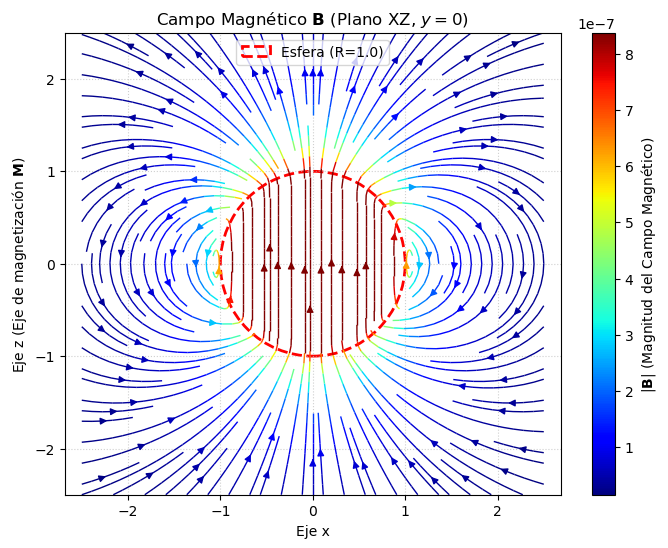

In [81]:
# =======================================================
# 3. Visualización del Campo Magnético B (Plano XZ)
# =======================================================
plt.figure(figsize=(8, 6)) 

# Usamos Bx_plot y Bz_plot para el streamplot en el plano (X, Z)
plt.streamplot(X, Z, Bx_plot, Bz_plot, color=velocidad_B, cmap='jet', density=1.5, linewidth=1)
plt.colorbar(label=r'$|\mathbf{B}|$ (Magnitud del Campo Magnético)')

# Trazar la sección transversal de la esfera
circulo_B = plt.Circle((0, 0), R, color='red', fill=False, linestyle='--', linewidth=2, label=f'Esfera (R={R})')
plt.gca().add_artist(circulo_B)

plt.title(r'Campo Magnético $\mathbf{B}$ (Plano XZ, $y=0$)')
plt.xlabel('Eje x')
plt.ylabel('Eje z (Eje de magnetización $\mathbf{M}$)')
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('magnetic_field_stream.png')
plt.show()

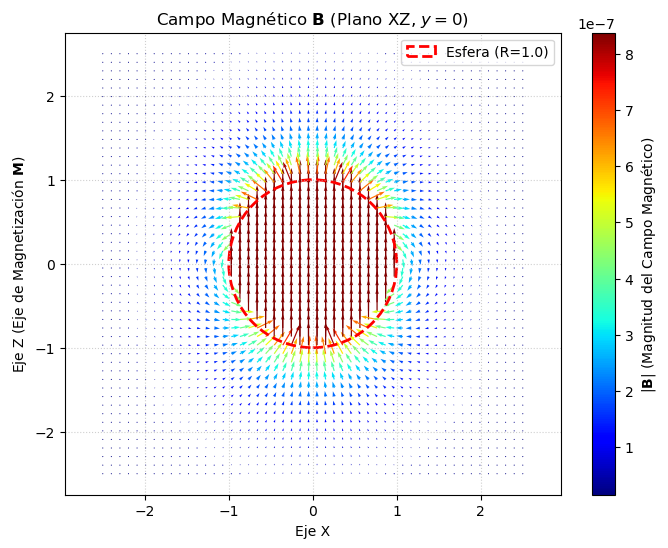

In [82]:
plt.figure(figsize=(8, 6)) 

# Usamos plt.quiver(X, Y, U, V, C)
# X, Z: Posición de las flechas (puntos de la malla)
# Bx_plot, Bz_plot: Componentes del vector (dirección y magnitud)
# velocidad_B: Color basado en la magnitud (opcional, pero útil)
plt.quiver(X, Z, Bx_plot, Bz_plot, velocidad_B, 
           cmap='jet', scale=None, angles='xy', scale_units='xy') # 'scale=None' deja que matplotlib escale automáticamente
                                                                  # 'scale_units='xy'' asegura proporciones correctas

plt.colorbar(label=r'$|\mathbf{B}|$ (Magnitud del Campo Magnético)')

# Trazar la sección transversal de la esfera
circulo_B = plt.Circle((0, 0), R, color='red', fill=False, linestyle='--', linewidth=2, label=f'Esfera (R={R})')
plt.gca().add_artist(circulo_B)

plt.title(r'Campo Magnético $\mathbf{B}$ (Plano XZ, $y=0$)')
plt.xlabel('Eje X')
plt.ylabel('Eje Z (Eje de Magnetización $\mathbf{M}$)')
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('magnetic_field_quiver.png')
plt.show()